In [1]:
import os
import sys
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

In [2]:
from config import config_loader as config_loader
from src.data.preprocessing import load_and_filter_catalog
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc,f1_score, recall_score, precision_score

In [3]:
def load_rf_config(project_root):
    import os
    from src.utils.file_utils import create_save_dir, save_args_to_json
    from config.config_loader import load_args_from_yaml


    args = load_args_from_yaml(os.path.join(project_root, 'config/rf.yaml'))

    
    feature_cols = [
        'Num', 'Mag_max', 'Mag_mean', 'beta', 'b_lsq', 'a_lsq',
        'b_std_lsq', 'std_gr_lsq', 'b_mlk', 'a_mlk', 'b_std_mlk', 'std_gr_mlk',
        'dM_lsq', 'dM_mlk', 'Energy_sqrt', 'prob_x7_lsq', 'prob_x7_mlk',
        'zvalue'
    ] + [f"T_elaps{Mag}" for Mag in args.Mag_elaps]

    args.feature_cols = list(set(feature_cols))
    args.dMag = 0.1
    args_dict = OmegaConf.to_container(args, resolve=True)
   
    args.save_dir = create_save_dir(os.path.join(project_root,'checkpoints') , model_name='rf',args_dict=args_dict )
    args_dict.pop("save_dir", None)


    for key in list(args_dict.keys()):
        if key in {
            "model", "batch_size", "warmup_ratio", "learning_rate", "weight_decay",
            "scheduler_type", "scheduler_factor", "scheduler_patience", "scheduler_threshold",
            "scheduler_min_lr", "d_model", "d_rnn", "d_inner", "n_layers", "n_head", "d_k",
            "d_v", "t_dropout", "attn_type", "mlp_out", "mlp_dropout", "mlp_hdw", "epochs",
            "cuda_id",
        }:
            del args_dict[key]
    save_args_to_json(args_dict, args.save_dir)
    return args


In [4]:
args = load_rf_config(project_root)

In [5]:
args.save_dir

'/root/autodl-tmp/chuandian_eq/checkpoints/rf_7310e627'

In [6]:
base_dir = os.path.join(project_root,  f"data/{args.dataset}")
df = load_and_filter_catalog(base_dir, Mc=args.Mc)

CSV files found: ['Chuandian2021.csv']


In [7]:
condition = df['Magnitude'] > args.Mf
changes = condition.ne(condition.shift()).sum()
print(f"Number of changes in condition: {changes}")

Number of changes in condition: 482


In [8]:
from sklearn.preprocessing import MinMaxScaler

def preprocess_data(features_df, feature_cols):
    scaler = MinMaxScaler()
    feature = scaler.fit_transform(features_df[feature_cols])
    
    y = np.full(len(features_df), np.nan)
    y[features_df['shock_len'].values > 0] = 1
    y[features_df['Negative'].values == 1] = 0
    
    valid_mask = (y == 0) | (y == 1)
    y = y[valid_mask]
    feature = feature[valid_mask]
    
    print(f"Number of positive samples: {np.sum(y == 1)}")
    print(f"Number of negative samples: {np.sum(y == 0)}")
    return feature, y

# feature, y = preprocess_data(features_df, args.feature_cols)

In [9]:
def split_dataset(feature, y, train_ratio=0.8, val_ratio=0.1, seed=0, by_time=False,time_order = ('train', 'val', 'test')):
    from src.data.utils import get_split_indices
    train_idx, val_idx, test_idx = get_split_indices(
        len(y), train_ratio=train_ratio, val_ratio=val_ratio, seed=seed, by_time=by_time,time_order=time_order
    )

    f_train = feature[train_idx]
    f_val = feature[val_idx]
    f_test = feature[test_idx]
    y_train = y[train_idx]
    y_val = y[val_idx]
    y_test = y[test_idx]

    return f_train, f_val, f_test, y_train, y_val, y_test

# f_train, f_val, f_test, y_train, y_val, y_test = split_dataset(
#     feature, y, train_ratio=0.8, val_ratio=0.1, seed=0, by_time=args.split_by_time
# )

In [10]:
def print_sample_distribution(y, dataset_name):
    positive_samples = np.sum(y == 1)
    negative_samples = np.sum(y == 0)
    total_samples = len(y)
    positive_ratio = positive_samples / total_samples
    negative_ratio = negative_samples / total_samples

    print(f"Positive samples: {positive_samples}, Negative samples: {negative_samples}")
    print(f"Total samples: {total_samples}, Positive ratio: {positive_ratio:.2f}, Negative ratio: {negative_ratio:.2f}")
    print()

In [11]:
def prepare_data_rf(args, base_dir=base_dir):
    import src.features.seismic_features as sf
    from src.data.preprocessing import load_and_filter_catalog
    from src.data.utils import get_split_indices
    from src.utils.file_utils import save_or_load_data
    from sklearn.preprocessing import MinMaxScaler
    import numpy as np

    df = load_and_filter_catalog(base_dir, Mc=args.Mc)

    def generate_data():
        features_df, num_mag = sf.calculate_seismic_features(
            df.to_numpy(),
            Mc=args.Mc,
            Mf=args.Mf,
            Twindow=args.Twindow,
            Tfore=args.Tfore,
            dt=args.dt,
            dMag=args.dMag,
            Mag_elaps=args.Mag_elaps,
            L_max=60,
            context_len=args.context_len,
        )
        return {
            "features_df": features_df,
            "num_mag": num_mag
        }

    cached = save_or_load_data(
        base_path=base_dir,
        generate_fn=generate_data,
        sub_dir="processed/rf_classifier",
        prefix="rf",
        Mc=args.Mc,
        Mf=args.Mf,
        Twindow=args.Twindow,
        Tfore=args.Tfore,
        dt=args.dt,
        dMag=args.dMag,
        Mag_elaps=args.Mag_elaps,
        context_len=args.context_len
    )

    features_df = cached["features_df"]
    num_mag = cached["num_mag"]
    scaler = MinMaxScaler()
    feature = scaler.fit_transform(features_df[args.feature_cols])
    # feature = features_df[args.feature_cols].values

    y = np.full(len(features_df), np.nan)
   
   
    y[features_df["shock_len"].values > 0] = 1
    y[features_df["Negative"].values == 1] = 0
    
    valid_mask = (y == 0) | (y == 1)
    y = y[valid_mask]
    feature = feature[valid_mask]

    train_idx, val_idx, test_idx = get_split_indices(
        len(y), train_ratio=0.8, val_ratio=0.1, seed=0, by_time=args.split_by_time, time_order=args.time_order
    )

    f_train = feature[train_idx]
    f_val = feature[val_idx]
    f_test = feature[test_idx]
    y_train = y[train_idx]
    y_val = y[val_idx]
    y_test = y[test_idx]

    f_train = scaler.fit_transform(f_train)
    f_val = scaler.transform(f_val)
    
    f_test = scaler.transform(f_test)

    print_sample_distribution(y_train, "Training Set")
    print_sample_distribution(y_val, "Validation Set")
    print_sample_distribution(y_test, "Test Set")

    return df,features_df, f_train, f_val, f_test, y_train, y_val, y_test, num_mag

In [12]:
df,features_df, f_train, f_val, f_test, y_train, y_val, y_test, num_mag = prepare_data_rf(args)

CSV files found: ['Chuandian2021.csv']


[✔] Loading cached data from: /root/autodl-tmp/chuandian_eq/data/ChuanDian/processed/rf_classifier/rf_Mag_elaps_[5.5, 6, 6.5, 7]_Mc_3_Mf_5_Tfore_60_Twindow_180_context_len_1_dMag_0.1_dt_10.pkl
Positive samples: 673, Negative samples: 494
Total samples: 1167, Positive ratio: 0.58, Negative ratio: 0.42

Positive samples: 87, Negative samples: 58
Total samples: 145, Positive ratio: 0.60, Negative ratio: 0.40

Positive samples: 48, Negative samples: 99
Total samples: 147, Positive ratio: 0.33, Negative ratio: 0.67



In [13]:
df['Magnitude'].max()

np.float64(8.0)

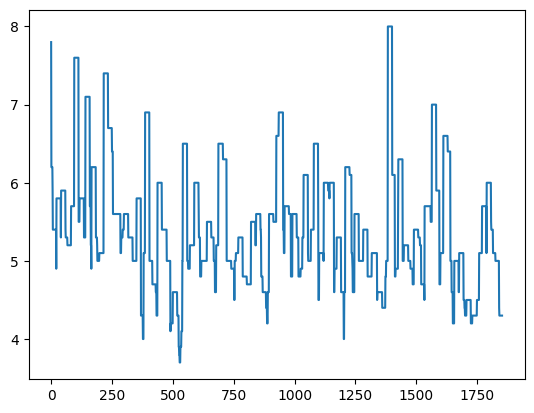

In [14]:
plt.plot(features_df['Mag_max'])

In [15]:
print(features_df.columns)

Index(['t', 'Num', 'Mag_max', 'Mag_max_obs', 'Mag_mean', 'b_lsq', 'a_lsq',
       'b_std_lsq', 'std_gr_lsq', 'b_mlk', 'a_mlk', 'b_std_mlk', 'std_gr_mlk',
       'dM_lsq', 'dM_mlk', 'Energy_sqrt', 'prob_x7_lsq', 'prob_x7_mlk',
       'zvalue', 'beta', 'shock_len', 'Negative', 'T_elaps5.5', 'T_elaps6',
       'T_elaps6.5', 'T_elaps7'],
      dtype='object')


In [16]:
features_df

,t,Num,Mag_max,Mag_max_obs,Mag_mean,b_lsq,a_lsq,b_std_lsq,std_gr_lsq,b_mlk,...,prob_x7_lsq,prob_x7_mlk,zvalue,beta,shock_len,Negative,T_elaps5.5,T_elaps6,T_elaps6.5,T_elaps7
0,184.04206,523.0,7.8,5.4,3.565774,0.645056,1.321662,0.319935,18.242181,0.767611,...,0.011610,0.004979,1.027063,-19.090770,2.0,0.0,112.951863,129.620150,180.000000,180.000000
1,194.04206,127.0,6.2,5.4,3.580315,0.649991,1.226071,0.239655,12.083030,0.748377,...,0.011221,0.005687,0.819893,-5.414792,1.0,0.0,122.951863,139.620150,190.000000,190.000000
2,204.04206,102.0,6.2,5.4,3.627451,0.619036,1.192217,0.212064,10.992155,0.692157,...,0.013896,0.008386,0.567796,-3.681868,1.0,0.0,132.951863,149.620150,200.000000,200.000000
3,214.04206,93.0,6.2,3.7,3.615054,0.578868,1.169543,0.186647,9.601236,0.706108,...,0.018340,0.007615,0.236447,-1.305077,0.0,0.0,142.951863,159.620150,210.000000,210.000000
4,224.04206,88.0,6.2,3.7,3.576136,0.586618,1.129434,0.195629,9.975206,0.753805,...,0.017384,0.005478,0.032465,0.233771,0.0,0.0,152.951863,169.620150,220.000000,220.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1848,18664.04206,175.0,4.3,4.3,3.316000,1.459246,1.558570,0.711103,33.859263,1.374350,...,0.000042,0.000075,0.879844,-3.531675,0.0,1.0,582.612919,599.086691,2378.354421,2848.706788
1849,18674.04206,170.0,4.3,4.3,3.314706,1.520028,1.544052,0.772795,36.909715,1.380001,...,0.000028,0.000072,0.941835,-3.524733,0.0,1.0,592.612919,609.086691,2388.354421,2858.706788
1850,18684.04206,171.0,4.3,4.3,3.314620,1.524404,1.544561,0.777333,37.123120,1.380378,...,0.000027,0.000072,0.731963,-2.821737,0.0,1.0,602.612919,619.086691,2398.354421,2868.706788
1851,18694.04206,167.0,4.3,4.3,3.322156,1.492416,1.547457,0.738250,35.537565,1.348089,...,0.000033,0.000090,0.602766,-2.560206,0.0,1.0,612.612919,629.086691,2408.354421,2878.706788


In [17]:
features_df[features_df['Num']==min(features_df['Num'])]

,t,Num,Mag_max,Mag_max_obs,Mag_mean,b_lsq,a_lsq,b_std_lsq,std_gr_lsq,b_mlk,...,prob_x7_lsq,prob_x7_mlk,zvalue,beta,shock_len,Negative,T_elaps5.5,T_elaps6,T_elaps6.5,T_elaps7
818,8364.04206,32.0,4.7,5.5,3.346875,0.976673,0.978338,0.384558,19.121968,1.25202,...,0.001175,0.000175,-0.356812,2.039455,2.0,0.0,1159.607475,1159.607475,1309.616134,6023.125127


In [18]:
# features_df[[f"T_elaps{mag}" for mag in args.Mag_elaps if f"T_elaps{mag}" in features_df.columns]] = \
#     features_df[[f"T_elaps{mag}" for mag in args.Mag_elaps if f"T_elaps{mag}" in features_df.columns]].clip(upper=args.Twindow)
# features_df['T_elaps5.5'].max()

In [19]:
# (features_df[[f"T_elaps{mag}" for mag in args.Mag_elaps if f"T_elaps{mag}" in features_df.columns]] <= 0).any().any()

In [20]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
# rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(f_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [21]:
y_prob = rf.predict_proba(f_test)[:, 1]  # 取正类的概率
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

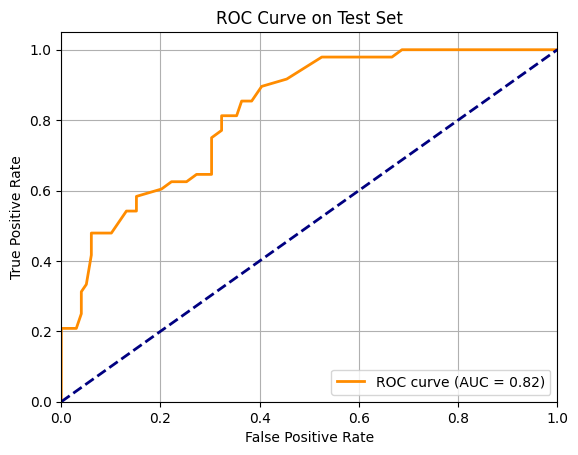

In [22]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # 参考线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig(os.path.join(args.save_dir, 'roc_curve.png'))
plt.show()

In [23]:
import os
import json
from src.utils.metrics import classification_metrics

y_val_prob = rf.predict_proba(f_val)[:, 1]
val_metrics = classification_metrics(y_val, y_val_prob)


val_metrics_path = os.path.join(args.save_dir, 'val_metrics.json')
with open(val_metrics_path, 'w') as f:
    json.dump(val_metrics, f, indent=2)   
    
y_prob = rf.predict_proba(f_test)[:, 1]
test_metrics = classification_metrics(y_test, y_prob)

if "recall" in test_metrics and "precision" in test_metrics:
    test_metrics["R"] = test_metrics["recall"] * test_metrics["precision"]

test_metrics_path = os.path.join(args.save_dir, 'test_metrics.json')
with open(test_metrics_path, 'w') as f:
    json.dump(test_metrics, f, indent=2)


In [24]:
args.save_dir

'/root/autodl-tmp/chuandian_eq/checkpoints/rf_7310e627'

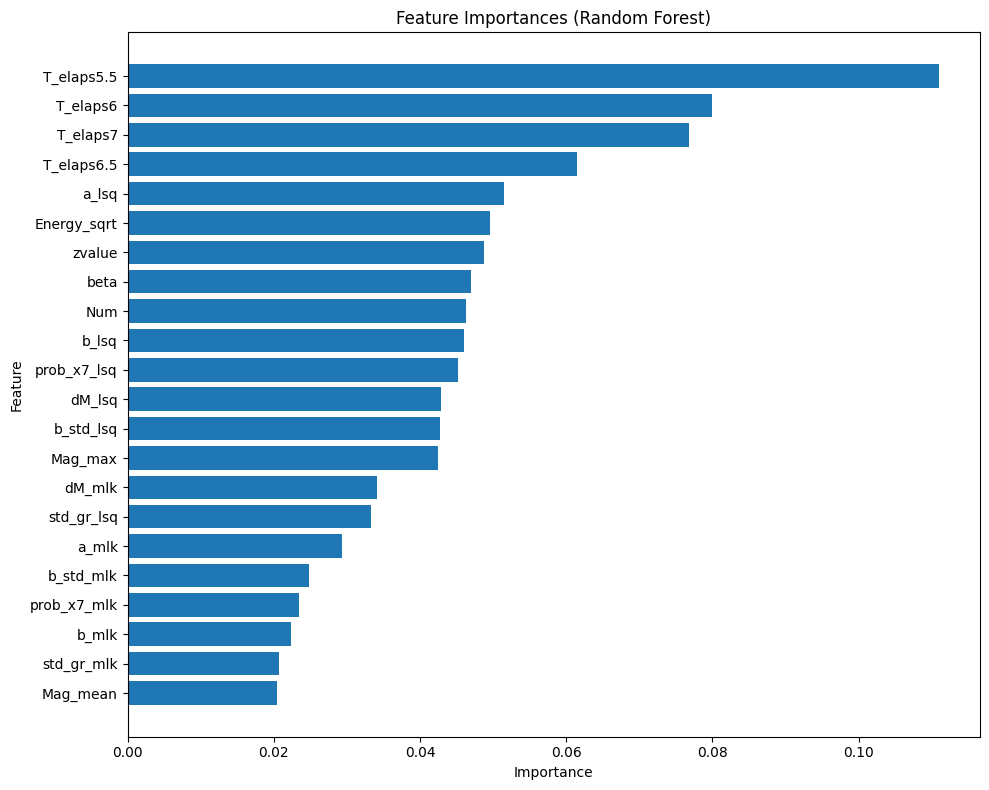

In [25]:
importances = rf.feature_importances_
feature_names = args.feature_cols

indices = np.argsort(importances)[::-1]
sorted_names = [feature_names[int(i)] for i in indices]
sorted_importances = importances[indices]

plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_importances)), sorted_importances, align="center")
plt.yticks(range(len(sorted_importances)), sorted_names)
plt.ylabel("Feature")
plt.xlabel("Importance")
plt.title("Feature Importances (Random Forest)")
plt.tight_layout()
plt.gca().invert_yaxis()  
plt.savefig(os.path.join(args.save_dir, 'feature_importances.png'))
plt.show()